In [1]:
"""
Ion Trapping and Secondary Species Analysis
==============================================
Produces:
  - Figure 3.3: RFQ ion trapping and extraction cycle
  - Figure 3.11: Loading vs. bunch classification example
  - Figure 4.2: Emergence of a secondary species with increasing storage time
  - Figure 4.3: Peak area vs. storage time -- low vs. high buffer gas pressure
  - Figure 4.4: Peak area vs. storage time -- PTFE vs. copper gas inlet tubing

Run parameters:
  1: ~3.583e-3 mbar (actively pumping, pressure drifting), 500ms period / 200us width
  2: ~4.389e-3 mbar (low pressure), period & width varied
  3: ~6.118e-2 mbar (high pressure, PTFE tubing), period & width varied
  4: ~5.294e-2 mbar (high pressure, copper tubing), period & width varied
Run 1 is excluded from all analysis below (superseded by Runs 2-4).
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import glob
import re
from scipy.optimize import curve_fit, least_squares
from matplotlib.patches import ConnectionPatch

RUN_CONFIG = {
    1: {"binwidth": 128, "range": 2048},
    2: {"binwidth": 128, "range": 2048},
    3: {"binwidth": 128, "range": 2048},
    4: {"binwidth": 128, "range": 2048},
}
RUN_COLORS = {1: "tab:red", 2: "tab:orange", 3: "tab:green", 4: "tab:blue"}  # Run 1 excluded from analysis

In [2]:
# === File parsing & raw data reading ===

def parse_trap_filename(filepath):
    """Extract exit-aperture delay (us) and run number from filenames like
    trap_100.mpa (100us delay, run 1), trap_100_2.mpa (run 2),
    or trap_overlap.mpa (control: DC transport only, no storage)."""
    basename = filepath.split("/")[-1]

    overlap_match = re.match(r"trap_overlap(?:_(\d+))?\.mpa$", basename)
    if overlap_match:
        run = int(overlap_match.group(1)) if overlap_match.group(1) else 1
        return 0.0, run, True  # delay=0, is_control=True

    match = re.match(r"trap_(\d+(?:\.\d+)?)(?:_(\d+))?\.mpa$", basename)
    if match is None:
        return None
    delay_us = float(match.group(1))
    run = int(match.group(2)) if match.group(2) else 1
    return delay_us, run, False


def read_mpa_file(filepath):
    """Parses REALTIME and TOTALSUM from an MPANT ASCII export."""
    realtime, totalsum = None, None
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())
    return realtime, totalsum


def get_rate_and_uncertainty(filepath):
    realtime, totalsum = read_mpa_file(filepath)
    if realtime is None or totalsum is None:
        print(f"WARNING: couldn't parse REALTIME/TOTALSUM from {filepath}, skipping")
        return None, None
    rate = totalsum / realtime
    rate_unc = np.sqrt(totalsum) / realtime
    return rate, rate_unc


def read_mpa_histogram(filepath, channels):
    """Reads the full [TDAT0,N] histogram block from an MPA file.
    Returns (realtime, totalsum, counts_array)."""
    realtime, totalsum = None, None
    counts = []
    in_data_block = False

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())
            elif line.startswith("[TDAT"):
                in_data_block = True
                continue
            elif in_data_block:
                if line.startswith("["):
                    break
                if line:
                    counts.append(int(line))

    return realtime, totalsum, np.array(counts)

In [3]:
# === Bunch shape fitting & classification (Section 3.6.4) ===

def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-((x - mu)**2) / (2*sigma**2)) + offset


def fit_gaussian_peak(filepath, window, binwidth=256, channels=2048, base_ns=0.8):
    """Fits a single Gaussian within a specified time window (us), with bounds
    to prevent degenerate fits on weak/noisy data."""
    realtime, totalsum, counts = read_mpa_histogram(filepath, channels)
    ns_per_channel = base_ns * binwidth
    time_us = np.arange(len(counts)) * ns_per_channel / 1000

    mask = (time_us >= window[0]) & (time_us < window[1])
    x, y = time_us[mask], counts[mask]
    if len(x) < 5 or y.max() == 0:
        return None

    p0 = [y.max(), x[np.argmax(y)], (window[1]-window[0])/6, 0]
    bounds = (
        [0,         window[0], 1e-3,                  -y.max()],
        [y.max()*3, window[1], (window[1]-window[0]), y.max()]
    )
    try:
        popt, pcov = curve_fit(gaussian, x, y, p0=p0, bounds=bounds, maxfev=10000)
    except Exception:
        return None

    y_pred = gaussian(x, *popt)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    perr = np.sqrt(np.diag(pcov))

    return {"amplitude": popt[0], "mu_us": popt[1], "sigma_us": popt[2], "offset": popt[3],
            "sigma_err_us": perr[2], "r2": r2}


def fit_gaussian_on_residual(residual, time_us, window, noise_region=(0, 5), min_snr=5):
    """Fits a Gaussian to the residual within `window`. Returns None if the
    fitted amplitude isn't meaningfully above the residual's own noise floor
    (measured in a flat, peak-free region), rather than accepting spurious
    fits to noise fluctuations."""
    mask = (time_us >= window[0]) & (time_us < window[1])
    x, y = time_us[mask], residual[mask]
    if len(x) < 5 or y.max() <= 0:
        return None

    noise_mask = (time_us >= noise_region[0]) & (time_us < noise_region[1])
    noise_std = residual[noise_mask].std() if noise_mask.sum() > 5 else np.inf

    p0 = [y.max(), x[np.argmax(y)], (window[1]-window[0])/6, 0]
    try:
        popt, pcov = curve_fit(gaussian, x, y, p0=p0, maxfev=10000)
    except Exception:
        return None

    amplitude = popt[0]
    if amplitude < min_snr * noise_std:
        return None

    perr = np.sqrt(np.diag(pcov))
    return {"amplitude": amplitude, "mu_us": popt[1], "sigma_us": popt[2], "offset": popt[3],
            "sigma_err_us": perr[2], "snr": amplitude/noise_std}


def measure_tail_contamination(filepath, binwidth, channels, base_ns=0.8,
                                 peak_window=(5, 20), valley_region=(18, 24)):
    """Checks the LOCAL MINIMUM in the valley between peak 1 and peak 2 --
    a genuine DC-transport pedestal shows a plateau (valley never dips down),
    while real peak-2 growth still has a proper local dip at this point,
    even once peak 2 itself has grown substantially further out."""
    realtime, totalsum, counts = read_mpa_histogram(filepath, channels)
    ns_per_channel = base_ns * binwidth
    time_us = np.arange(len(counts)) * ns_per_channel / 1000

    peak_mask = (time_us >= peak_window[0]) & (time_us < peak_window[1])
    if peak_mask.sum() == 0 or counts[peak_mask].max() == 0:
        return None
    peak_height = counts[peak_mask].max()

    valley_mask = (time_us >= valley_region[0]) & (time_us < valley_region[1])
    if valley_mask.sum() == 0:
        return None
    valley_min = counts[valley_mask].min()

    return valley_min / peak_height


def classify_bunch_quality(filepath, binwidth, channels, expected_mu1=None,
                            mu1_tolerance_us=5, tail_frac_threshold=0.05,
                            peak_window=(5, 20), valley_region=(18, 24)):
    fit = fit_gaussian_peak(filepath, peak_window, binwidth=binwidth, channels=channels)
    if fit is None:
        return "unresolved", None

    tail_frac = measure_tail_contamination(filepath, binwidth, channels,
                                             peak_window=peak_window, valley_region=valley_region)
    if tail_frac is None or tail_frac > tail_frac_threshold:
        return "loading", fit

    if expected_mu1 is not None and abs(fit["mu_us"] - expected_mu1) > mu1_tolerance_us:
        return "merged", fit

    return "bunch", fit


def apply_bunch_hysteresis(df):
    """No-op: kept for compatibility, but no longer overrides classifications.
    Each delay is now judged independently on its own widened-window R^2 test,
    since bunch quality does not improve monotonically with cooling time."""
    return df


def bunch_shape_metrics(filepath, binwidth=128, channels=2048, base_ns=0.8):
    """Extracts total counts, peak-integrated ions-per-bunch, and bunch width
    (FWHM, in us) from a single MPA histogram file."""
    realtime, totalsum, counts = read_mpa_histogram(filepath, channels)
    if len(counts) == 0:
        print(f"WARNING: no histogram data found in {filepath}")
        return None

    ns_per_channel = base_ns * binwidth
    peak_idx = np.argmax(counts)
    peak_height = counts[peak_idx]
    half_max = peak_height / 2

    left, right = counts[:peak_idx + 1], counts[peak_idx:]
    left_idx = np.where(left <= half_max)[0]
    right_idx = np.where(right <= half_max)[0]

    if len(left_idx) == 0 or len(right_idx) == 0:
        print(f"WARNING: could not resolve FWHM for {filepath} (peak too close to edge)")
        fwhm_us = None
    else:
        ch_left = left_idx[-1]
        ch_right = peak_idx + right_idx[0]
        fwhm_us = ((ch_right - ch_left) * ns_per_channel) / 1000

    roi_half_width = int(2 * (fwhm_us*1000/ns_per_channel)) if fwhm_us else 5
    roi_start = max(0, peak_idx - roi_half_width)
    roi_end = min(len(counts), peak_idx + roi_half_width)
    ions_per_bunch = counts[roi_start:roi_end].sum()

    return {"realtime": realtime, "totalsum": totalsum, "peak_channel": peak_idx,
            "peak_height": peak_height, "fwhm_us": fwhm_us, "ions_per_bunch": ions_per_bunch}


def dual_peak_metrics(filepath, binwidth=256, channels=2048, base_ns=0.8,
                       peak1_window=(5, 20), peak2_window=(22, 45)):
    """Integrates counts within two fixed time windows (us) to track the
    primary bunch (peak1) and the growing secondary feature (peak2)
    separately across storage delays."""
    realtime, totalsum, counts = read_mpa_histogram(filepath, channels)
    if len(counts) == 0:
        return None

    ns_per_channel = base_ns * binwidth
    time_us = np.arange(len(counts)) * ns_per_channel / 1000
    mask1 = (time_us >= peak1_window[0]) & (time_us < peak1_window[1])
    mask2 = (time_us >= peak2_window[0]) & (time_us < peak2_window[1])
    peak1_area, peak2_area = counts[mask1].sum(), counts[mask2].sum()

    return {"realtime": realtime, "totalsum": totalsum, "peak1_area": peak1_area,
            "peak2_area": peak2_area, "combined_area": peak1_area + peak2_area}


def cooling_relaxation(t, W0, Weq, tau):
    return (W0 - Weq) * np.exp(-t/tau) + Weq

In [4]:
# === Overview-grid plotting helpers ===

def format_delay_label(delay_us):
    """Format a delay in microseconds using the best-fitting metric unit."""
    delay_s = delay_us * 1e-6
    return ticker.EngFormatter(unit="s")(delay_s)


def plot_bunch_histogram_overlay(ax, file_run_quality, base_ns=0.8, peak1_window=(5, 20), title=None):
    """file_run_quality: list of (filepath, run_num, is_bunch) tuples.
    Each run's FWHM bracket is only drawn if that specific run's own quality is 'bunch'."""
    for filepath, run_num, is_bunch in file_run_quality:
        cfg = RUN_CONFIG[run_num]
        realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
        ns_per_channel = base_ns * cfg["binwidth"]
        time_us = np.arange(len(counts)) * ns_per_channel / 1000
        color = RUN_COLORS[run_num]
        ax.step(time_us, counts, where='mid', color=color, alpha=0.8, label=f"Run {run_num}")

        if is_bunch:
            fit1 = fit_gaussian_peak(filepath, peak1_window, binwidth=cfg["binwidth"], channels=cfg["range"])
            if fit1 is not None:
                fwhm = fit1["sigma_us"] * 2.3548
                mu = fit1["mu_us"]
                half_max_y = fit1["amplitude"]/2 + fit1["offset"]
                ax.plot([mu-fwhm/2, mu+fwhm/2], [half_max_y, half_max_y], color=color, linewidth=2)

    ax.set_xlabel("Time (us)")
    ax.set_ylabel("Counts")
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)


def plot_bunch_histogram_overlay_zoomed(ax, file_run_pairs, base_ns=0.8,
                                          peak1_window=(5, 20), peak2_window=(22, 45),
                                          peak2_min_amplitude_frac=0.03,
                                          zoom_window_us=40, title=None):
    peak1_mu_list = []
    for filepath, run_num in file_run_pairs:
        cfg = RUN_CONFIG[run_num]
        realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
        ns_per_channel = base_ns * cfg["binwidth"]
        time_us = np.arange(len(counts)) * ns_per_channel / 1000
        color = RUN_COLORS[run_num]
        ax.step(time_us, counts, where='mid', color=color, alpha=0.8, label=f"Run {run_num}")

        fit1 = fit_gaussian_peak(filepath, peak1_window, binwidth=cfg["binwidth"], channels=cfg["range"])
        fit2 = fit_gaussian_peak(filepath, peak2_window, binwidth=cfg["binwidth"], channels=cfg["range"])

        if fit1 is not None:
            peak1_mu_list.append(fit1["mu_us"])
            fwhm = fit1["sigma_us"] * 2.3548
            mu = fit1["mu_us"]
            half_max_y = fit1["amplitude"]/2 + fit1["offset"]
            ax.plot([mu-fwhm/2, mu+fwhm/2], [half_max_y, half_max_y], color=color, linewidth=2)

        if fit2 is not None and fit1 is not None and fit2["amplitude"] > fit1["amplitude"]*peak2_min_amplitude_frac:
            fwhm2 = fit2["sigma_us"] * 2.3548
            mu2 = fit2["mu_us"]
            half_max_y2 = fit2["amplitude"]/2 + fit2["offset"]
            ax.plot([mu2-fwhm2/2, mu2+fwhm2/2], [half_max_y2, half_max_y2], color=color, linewidth=2, linestyle='--')

    if peak1_mu_list:
        center = np.mean(peak1_mu_list)
        ax.set_xlim(max(0, center - zoom_window_us/4), center + zoom_window_us)

In [5]:
"""
Build trap_df: classifies every collected scan as 'bunch' or 'loading' quality
(Section 3.6.4). expected_mu1 -- the reference peak-1 arrival time used for
that classification -- is established from a set of long-storage-time
reference scans, on the assumption that the primary bunch has fully
thermalized by that point.
"""

reference_mu = []
for f in glob.glob("IonTrap/trap_4000*.mpa") + glob.glob("IonTrap/trap_10000*.mpa") + glob.glob("IonTrap/trap_20000*.mpa"):
    parsed = parse_trap_filename(f)
    if parsed is None:
        continue
    delay_us, run, is_control = parsed
    if is_control:
        continue
    cfg = RUN_CONFIG[run]
    fit = fit_gaussian_peak(f, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
    if fit is not None:
        reference_mu.append(fit["mu_us"])

expected_mu1 = np.median(reference_mu)
mu1_tolerance_us = 5
print(f"expected_mu1 = {expected_mu1:.3f} us, from {len(reference_mu)} reference points")

trap_files = [f for f in glob.glob("IonTrap/trap_*.mpa") if "Noise" not in f]

trap_runs = []
for filepath in trap_files:
    parsed = parse_trap_filename(filepath)
    if parsed is None:
        continue
    delay_us, run, is_control = parsed
    cfg = RUN_CONFIG[run]

    rate, rate_unc = get_rate_and_uncertainty(filepath)
    shape = bunch_shape_metrics(filepath, binwidth=cfg["binwidth"], channels=cfg["range"])
    quality, gauss_fit = classify_bunch_quality(filepath, binwidth=cfg["binwidth"], channels=cfg["range"],
                                              expected_mu1=expected_mu1, mu1_tolerance_us=mu1_tolerance_us,
                                              tail_frac_threshold=0.05)
    row = {
        "filepath": filepath, "delay_us": delay_us, "run": run, "is_control": is_control,
        "rate_hz": rate, "rate_unc_hz": rate_unc, "quality": quality,
    }
    if shape is not None:
        row.update(shape)
    if gauss_fit is not None:
        row["r2"] = gauss_fit["r2"]
    trap_runs.append(row)

trap_df = pd.DataFrame(trap_runs).sort_values(["run", "delay_us"]).reset_index(drop=True)
trap_df = apply_bunch_hysteresis(trap_df)
trap_df = trap_df[trap_df["run"] != 1].reset_index(drop=True)

good_delays = sorted(trap_df[(trap_df["quality"] == "bunch") & (~trap_df["is_control"])]["delay_us"].unique())

expected_mu1 = 13.222 us, from 23 reference points


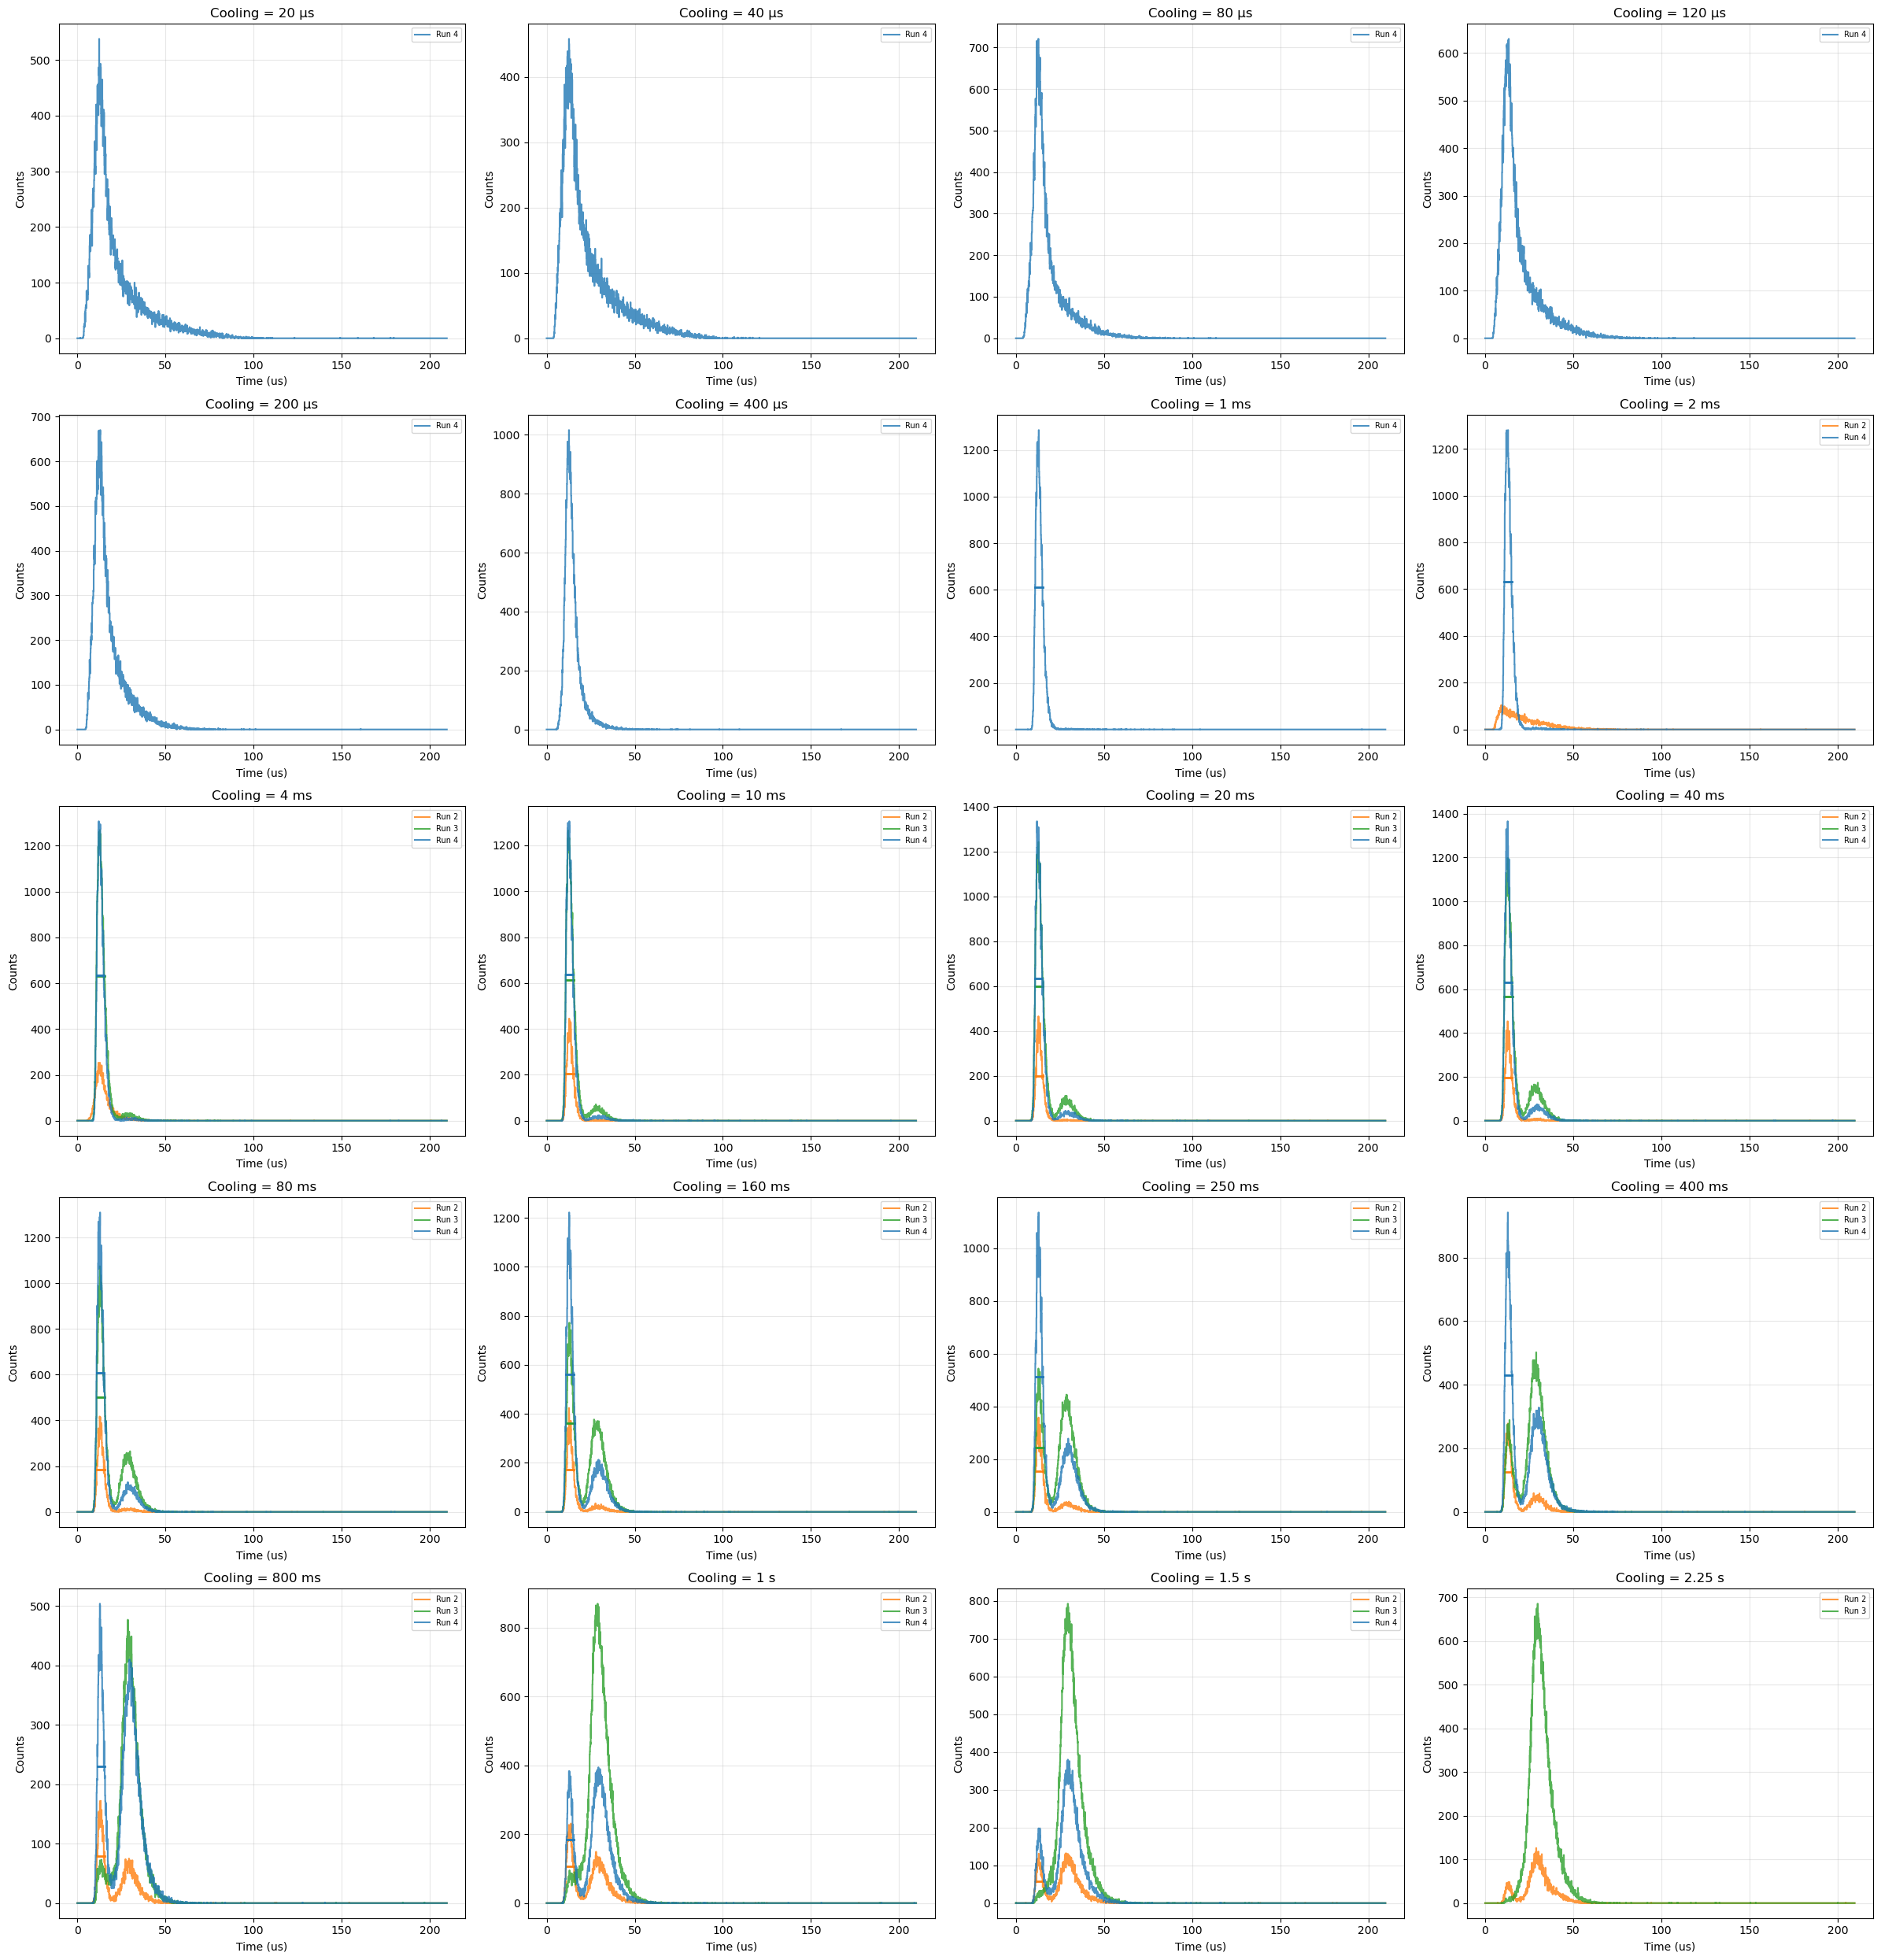

In [6]:
"""
Overview grids: three ways of surveying every collected scan before the
published figures below. storage_delays_all shows everything (loading and
bunch quality alike); good_pairs zooms in on the well-separated bunch-quality
scans only; run_delay_pairs is the detailed raw+fit diagnostic per scan.
"""

storage_delays_all = sorted(trap_df[~trap_df["is_control"]]["delay_us"].unique())
n_delays = len(storage_delays_all)
n_cols = 4
n_rows = int(np.ceil(n_delays / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()
for ax, delay in zip(axes, storage_delays_all):
    rows = trap_df[(trap_df["delay_us"] == delay) & (~trap_df["is_control"])]
    file_run_quality = list(zip(rows["filepath"], rows["run"], rows["quality"] == "bunch"))
    plot_bunch_histogram_overlay(ax, file_run_quality, title=f"Cooling = {format_delay_label(delay)}")
for ax in axes[n_delays:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

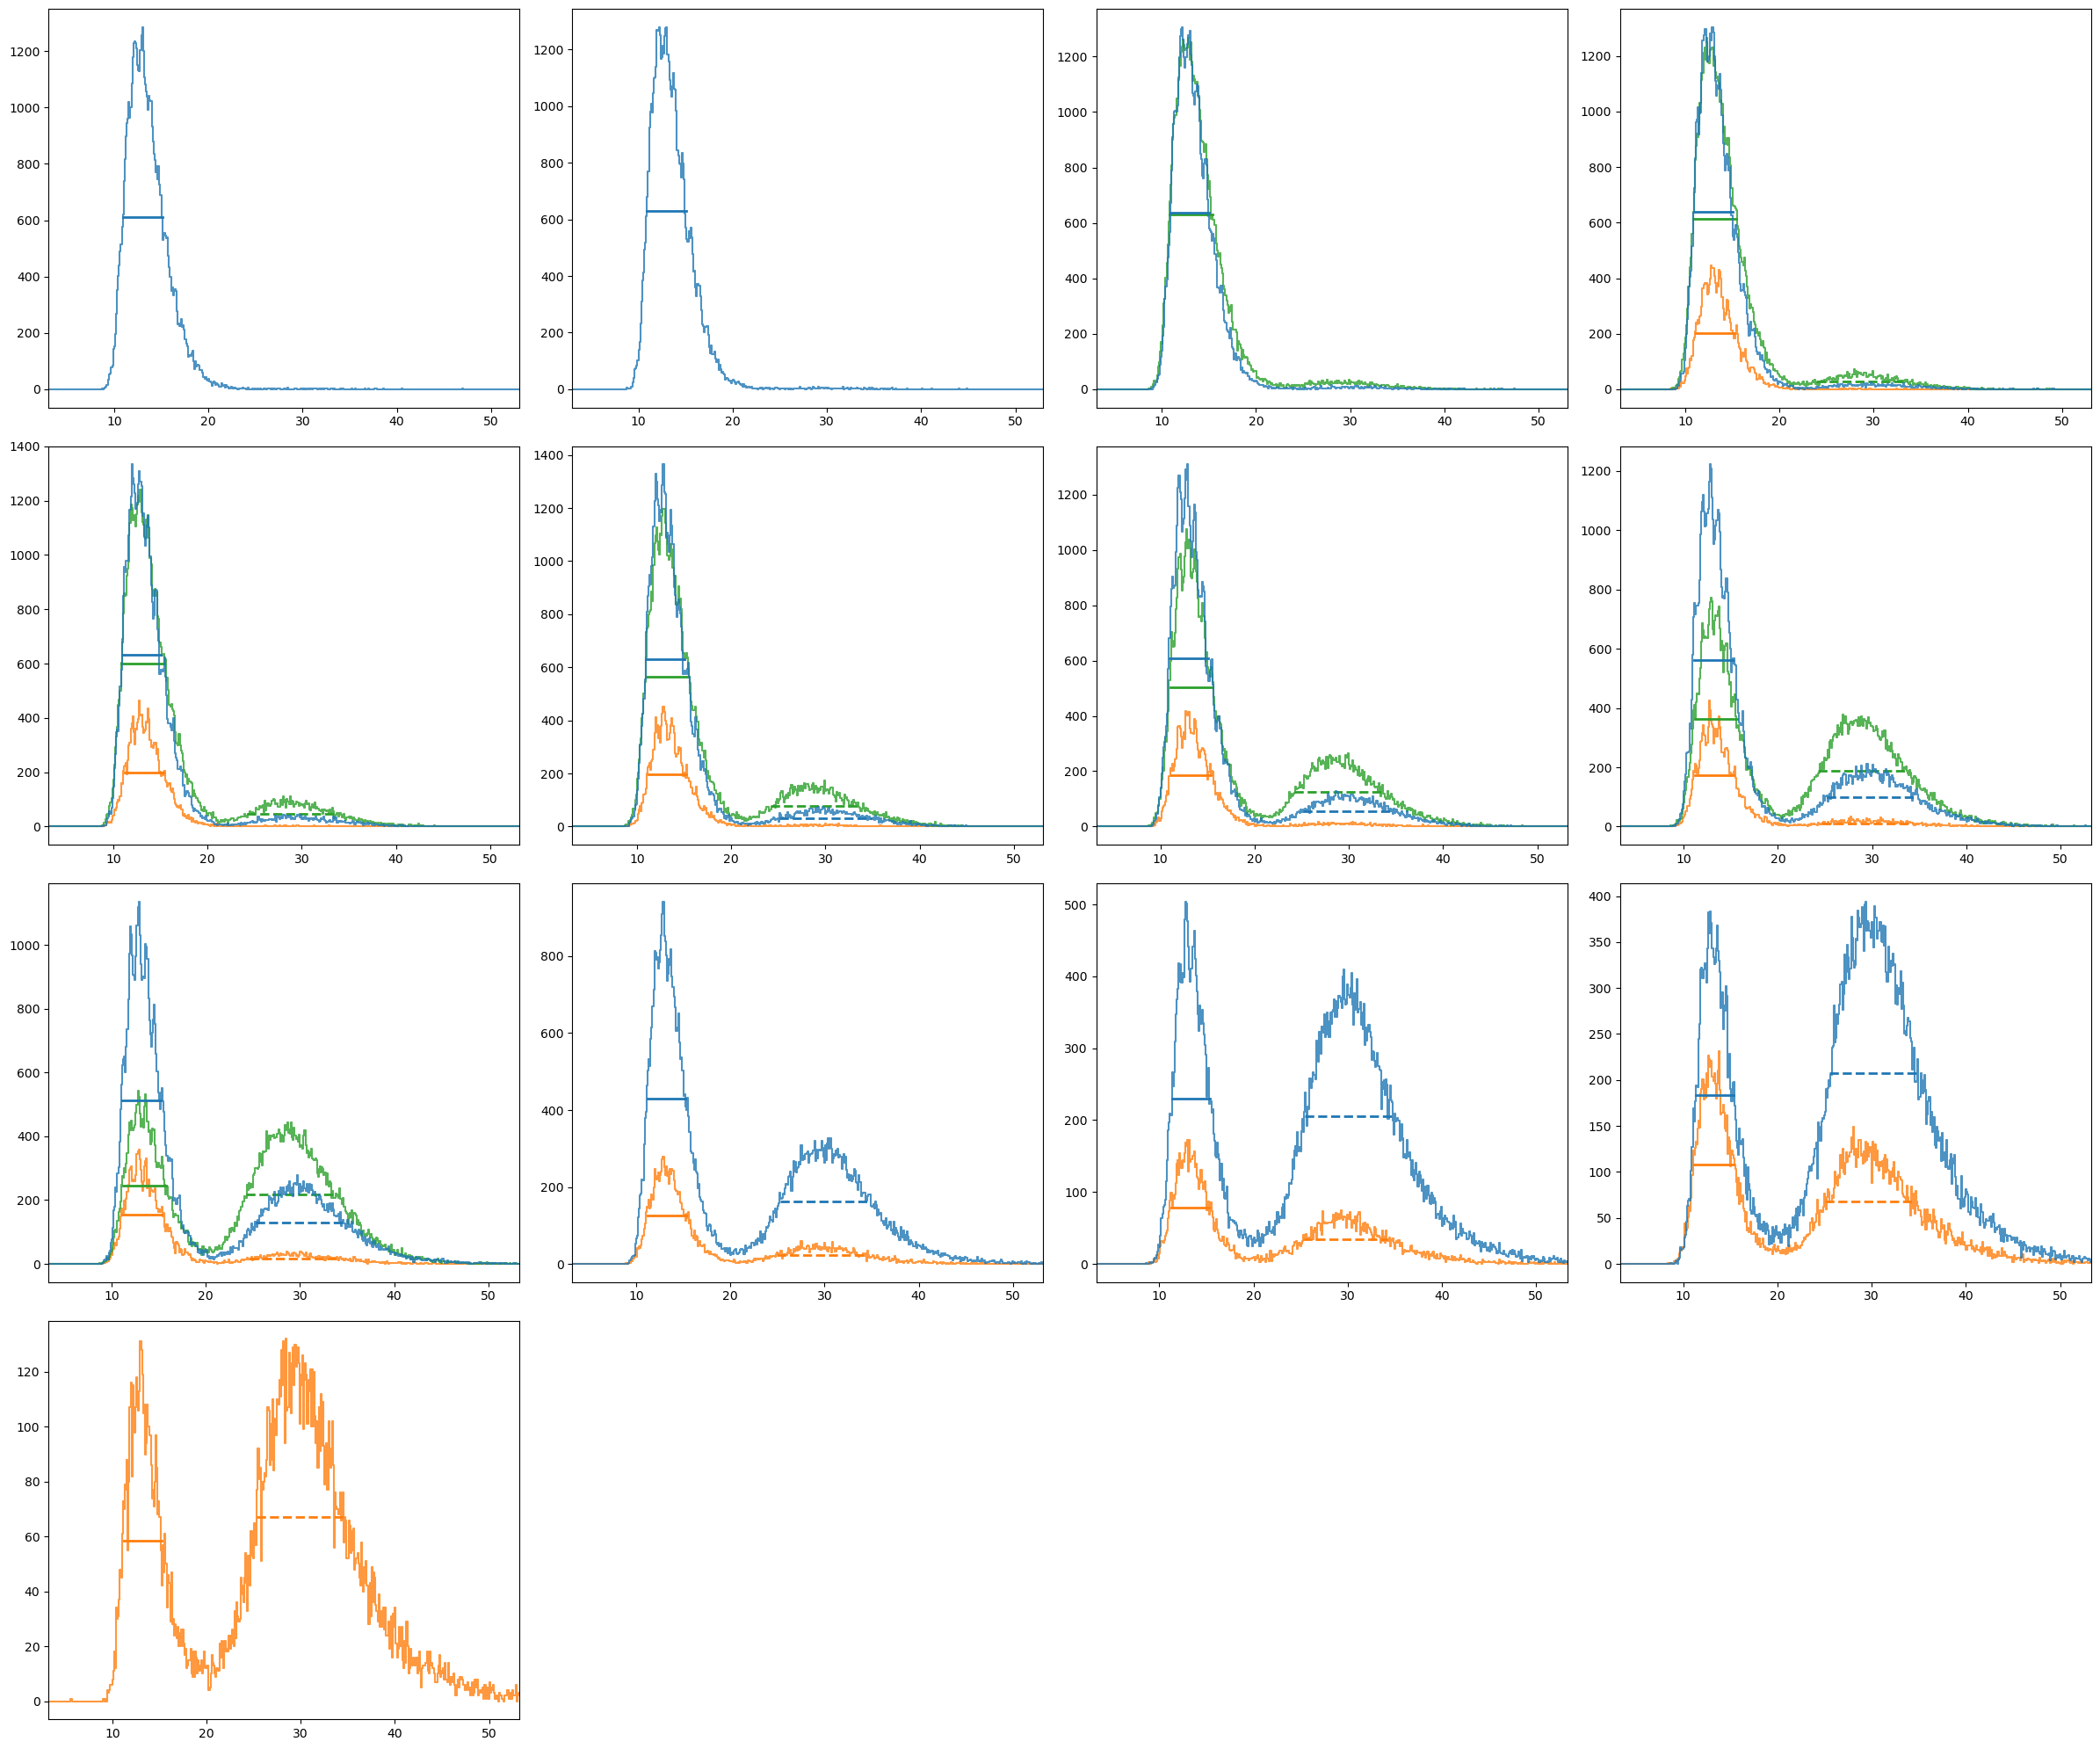

In [7]:
good_pairs = trap_df[(trap_df["quality"]=="bunch") & (~trap_df["is_control"])][["run","delay_us"]].drop_duplicates()

n_cols = 4
n_rows = int(np.ceil(good_pairs["delay_us"].nunique() / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()
for ax, delay in zip(axes, sorted(good_pairs["delay_us"].unique())):
    rows = trap_df[(trap_df["delay_us"] == delay) & (trap_df["quality"]=="bunch") & (~trap_df["is_control"])]
    file_run_pairs = list(zip(rows["filepath"], rows["run"]))
    plot_bunch_histogram_overlay_zoomed(ax, file_run_pairs, title=f"Cooling = {format_delay_label(delay)}")
for ax in axes[good_pairs['delay_us'].nunique():]:
    ax.axis('off')
plt.tight_layout()
plt.show()

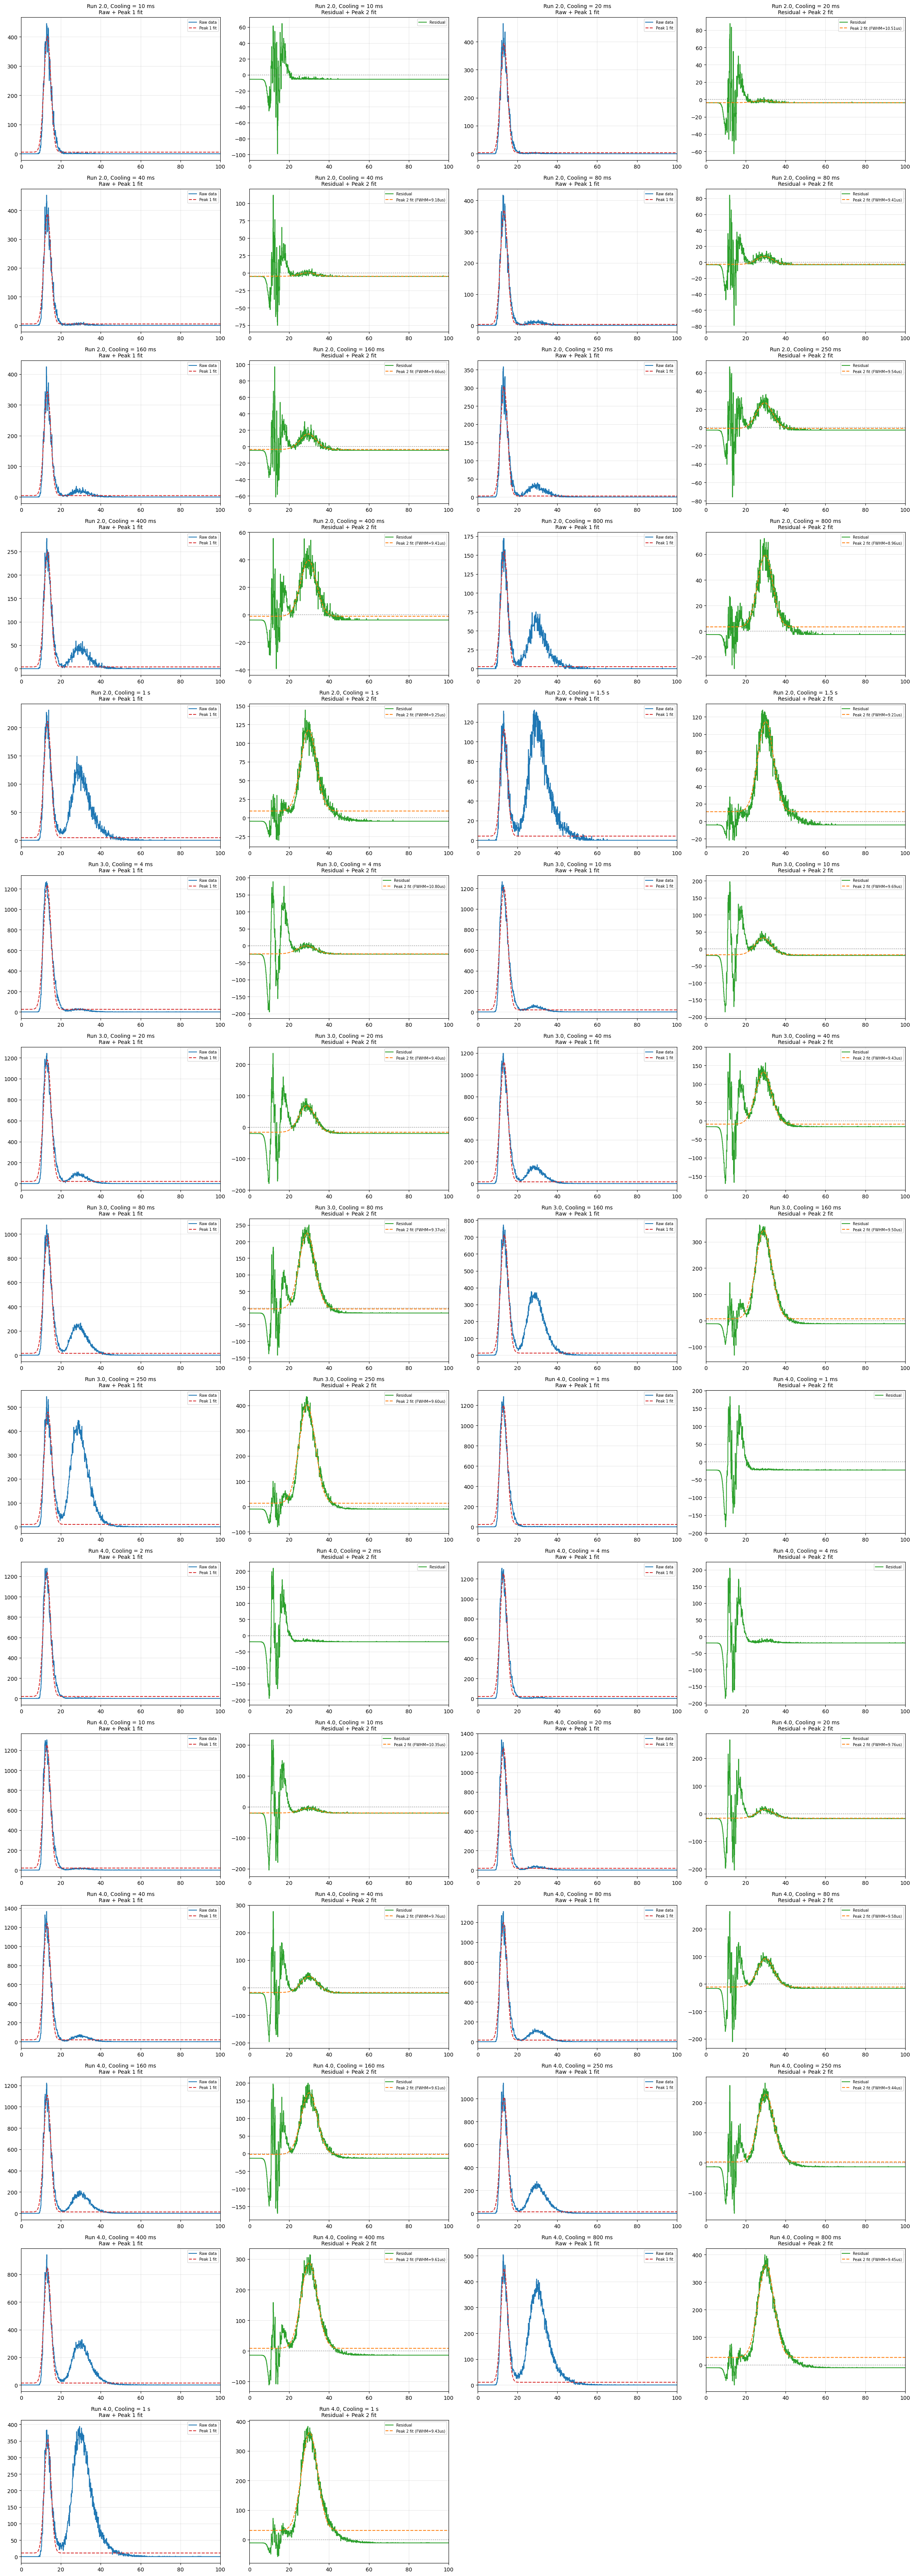

In [8]:
def plot_run_delay_diagnostic(ax_top, ax_bot, filepath, run_num, delay, cfg, expected_mu1, mu1_tolerance_us):
    """Plots raw histogram + Peak 1 Gaussian fit (top axis) and the residual +
    Peak 2 fit (bottom axis) for a single run/delay combination."""
    fit1 = fit_gaussian_peak(filepath, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
    if fit1 is not None and abs(fit1["mu_us"] - expected_mu1) > mu1_tolerance_us:
        fit1 = None

    title_base = f"Run {run_num}, Cooling = {format_delay_label(delay)}"
    realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
    ns_per_channel = cfg["binwidth"] * 0.8
    time_us = np.arange(len(counts)) * ns_per_channel / 1000

    if fit1 is None:
        ax_top.step(time_us, counts, where='mid', color='tab:blue', label='Raw data')
        ax_top.set_xlim(0, 100)
        ax_top.set_title(f"{title_base}\nPeak 1 unresolved", fontsize=10)
        ax_top.legend(fontsize=7)
        ax_top.grid(True, alpha=0.3)
        ax_bot.axis('off')
        return

    gaussian1_full = gaussian(time_us, fit1["amplitude"], fit1["mu_us"], fit1["sigma_us"], fit1["offset"])
    residual = counts - gaussian1_full
    fit2 = fit_gaussian_on_residual(residual, time_us, window=(22, 45))

    ax_top.step(time_us, counts, where='mid', color='tab:blue', label='Raw data')
    ax_top.plot(time_us, gaussian1_full, color='tab:red', linestyle='--', label='Peak 1 fit')
    ax_top.set_xlim(0, 100)
    ax_top.set_title(f"{title_base}\nRaw + Peak 1 fit", fontsize=10)
    ax_top.legend(fontsize=7)
    ax_top.grid(True, alpha=0.3)

    ax_bot.step(time_us, residual, where='mid', color='tab:green', label='Residual')
    if fit2 is not None:
        gaussian2_full = gaussian(time_us, fit2["amplitude"], fit2["mu_us"], fit2["sigma_us"], fit2["offset"])
        fwhm2 = fit2["sigma_us"] * 2.3548
        ax_bot.plot(time_us, gaussian2_full, color='tab:orange', linestyle='--',
                    label=f'Peak 2 fit (FWHM={fwhm2:.2f}us)')
    ax_bot.axhline(0, color='gray', linestyle=':', alpha=0.6)
    ax_bot.set_xlim(0, 100)
    ax_bot.set_title(f"{title_base}\nResidual + Peak 2 fit", fontsize=10)
    ax_bot.legend(fontsize=7)
    ax_bot.grid(True, alpha=0.3)


run_delay_pairs = (
    trap_df[(trap_df["quality"] == "bunch") & (~trap_df["is_control"])]
    [["run", "delay_us"]].drop_duplicates().sort_values(["run", "delay_us"]).reset_index(drop=True)
)
n_panels = len(run_delay_pairs)
pairs_per_row = 2  # 2 run-delay pairs per row, each spanning 2 columns (raw+fit1, residual+fit2)
n_cols = pairs_per_row * 2
n_rows = int(np.ceil(n_panels / pairs_per_row))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = np.atleast_2d(axes)

for i, (_, pair) in enumerate(run_delay_pairs.iterrows()):
    run_num, delay = pair["run"], pair["delay_us"]
    row = trap_df[(trap_df["delay_us"] == delay) & (trap_df["run"] == run_num) & (~trap_df["is_control"])]
    filepath = row["filepath"].iloc[0]
    cfg = RUN_CONFIG[run_num]
    grid_row, slot = divmod(i, pairs_per_row)
    ax_top, ax_bot = axes[grid_row, slot * 2], axes[grid_row, slot * 2 + 1]
    plot_run_delay_diagnostic(ax_top, ax_bot, filepath, run_num, delay, cfg, expected_mu1, mu1_tolerance_us)

for j in range(n_panels, n_rows * pairs_per_row):
    grid_row, slot = divmod(j, pairs_per_row)
    axes[grid_row, slot * 2].axis('off')
    axes[grid_row, slot * 2 + 1].axis('off')

plt.tight_layout()
plt.show()

Run 2: tau = 27.01 +/- 350.78 ms
Run 3: tau = 468163.95 +/- 5122860809.34 ms
Run 4: tau = 1298335.04 +/- 14579920581.93 ms


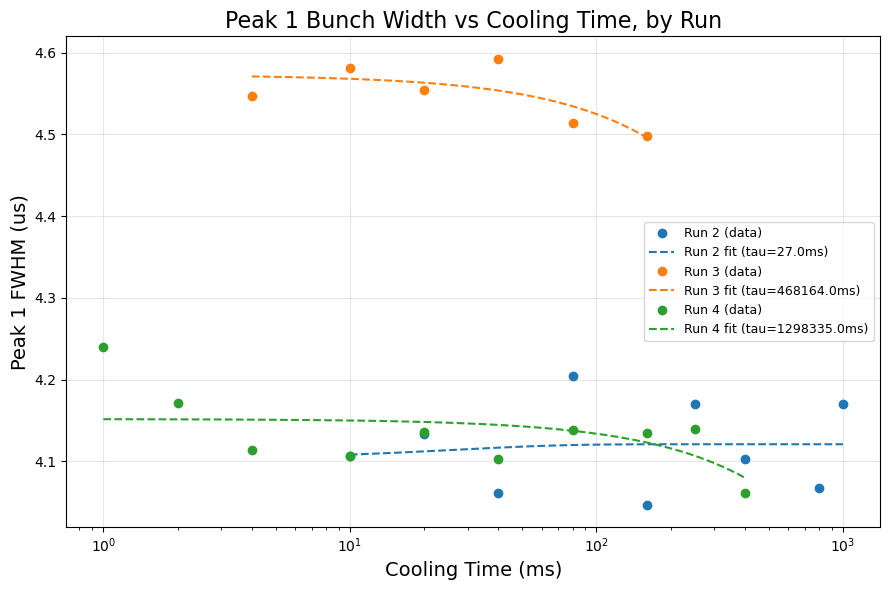

In [9]:
"""
Peak 1 bunch width vs. cooling time, by run -- a two-state relaxation model
(cooling toward an equilibrium width) fit to the FWHM data, where a stable
Peak 1 fit could be resolved and wasn't dominated by the emerging Peak 2.
"""

width_rows = []
for _, r in trap_df[(trap_df["quality"]=="bunch") & (~trap_df["is_control"])].iterrows():
    filepath, run_num, delay = r["filepath"], r["run"], r["delay_us"]
    cfg = RUN_CONFIG[run_num]

    fit1 = fit_gaussian_peak(filepath, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
    if fit1 is not None and abs(fit1["mu_us"] - expected_mu1) > mu1_tolerance_us:
        fit1 = None

    fwhm1 = None
    if fit1 is not None:
        realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
        ns_per_channel = cfg["binwidth"] * 0.8
        time_us = np.arange(len(counts)) * ns_per_channel / 1000
        gaussian_full = gaussian(time_us, fit1["amplitude"], fit1["mu_us"], fit1["sigma_us"], fit1["offset"])
        residual = counts - gaussian_full
        fit2_resid = fit_gaussian_on_residual(residual, time_us, window=(22, 45))

        if fit2_resid is None or fit1["amplitude"] > fit2_resid["amplitude"] * 1.5:
            fwhm1 = fit1["sigma_us"] * 2.3548

    width_rows.append({"delay_us": delay, "run": run_num, "fwhm1_us": fwhm1})

width_df = pd.DataFrame(width_rows).dropna(subset=["fwhm1_us"]).sort_values(["run", "delay_us"])

plt.figure(figsize=(9, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, (run_num, group) in enumerate(width_df.groupby("run")):
    color = colors[i % len(colors)]
    t_s = group["delay_us"].values * 1e-6
    plt.plot(group["delay_us"]/1000, group["fwhm1_us"], "o", color=color, label=f"Run {run_num} (data)")

    if len(group) >= 3:
        try:
            popt, pcov = curve_fit(cooling_relaxation, t_s, group["fwhm1_us"],
                                    p0=[group["fwhm1_us"].max(), group["fwhm1_us"].min(), 0.1], maxfev=10000)
            t_fit = np.linspace(t_s.min(), t_s.max(), 200)
            plt.plot(t_fit*1000, cooling_relaxation(t_fit, *popt), "--", color=color,
                     label=f"Run {run_num} fit (tau={popt[2]*1000:.1f}ms)")
            print(f"Run {run_num}: tau = {popt[2]*1000:.2f} +/- {np.sqrt(pcov[2,2])*1000:.2f} ms")
        except Exception as e:
            print(f"Run {run_num}: fit failed ({e})")

plt.xscale('log')
plt.xlabel("Cooling Time (ms)", fontsize=14)
plt.ylabel("Peak 1 FWHM (us)", fontsize=14)
plt.title("Peak 1 Bunch Width vs Cooling Time, by Run", fontsize=16)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
"""
dual_peak_df: per-scan integrated Peak 1 (primary bunch) and Peak 2
(secondary species) areas, at the "good" (bunch-quality) delays. This feeds
Figures 4.2, 4.3, and 4.4 below.
"""

dual_peak_rows = []
for _, r in trap_df[(trap_df["delay_us"].isin(good_delays)) & (~trap_df["is_control"])].iterrows():
    filepath, run_num, delay = r["filepath"], r["run"], r["delay_us"]
    cfg = RUN_CONFIG[run_num]
    metrics = dual_peak_metrics(filepath, binwidth=cfg["binwidth"], channels=cfg["range"])
    if metrics is None:
        continue
    metrics["delay_us"] = delay
    metrics["run"] = run_num
    dual_peak_rows.append(metrics)

dual_peak_df = pd.DataFrame(dual_peak_rows).sort_values(["run", "delay_us"]).reset_index(drop=True)

In [11]:
import os
import shutil

def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)

def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw/, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)
    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)
    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing

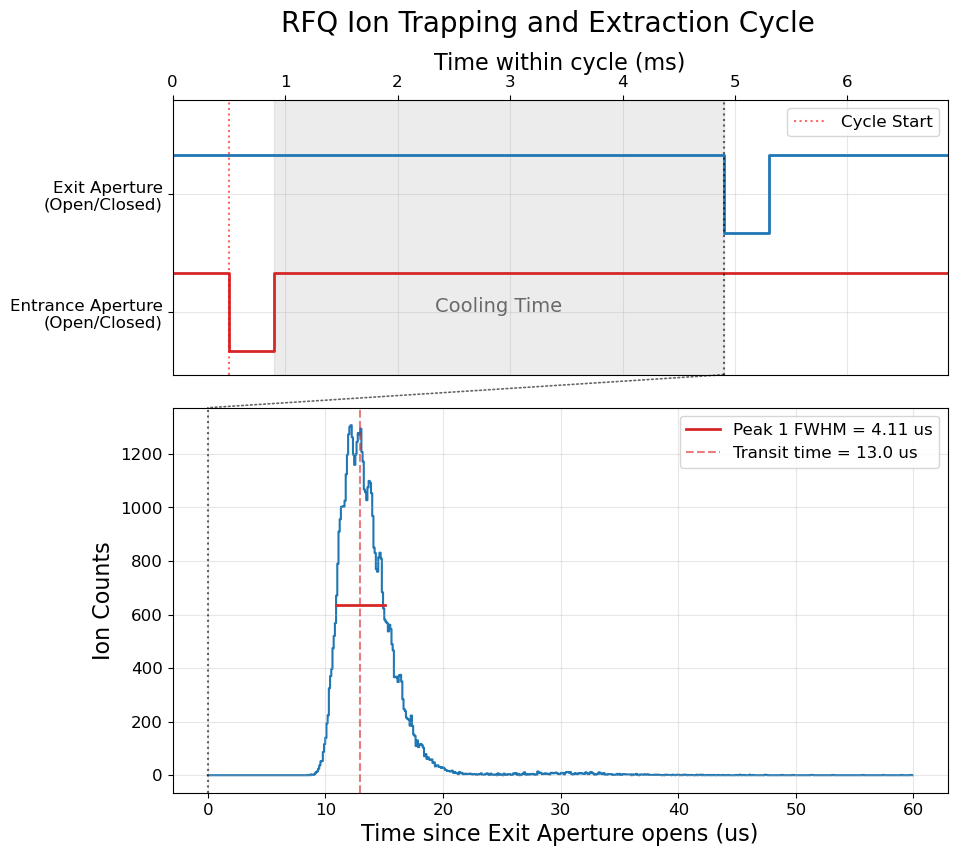

In [12]:
"""
Figure 3.3: RFQ Ion Trapping and Extraction Cycle
------------------------------------------------------
"""

def plot_trap_cycle_diagram(entrance_width_ms, exit_width_ms, storage_delay_ms,
                              example_filepath, example_run_num, tdc_window_us=60,
                              xlim_padding_factor=1.3):
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 9),
                                      gridspec_kw={'height_ratios': [1, 1.4], 'hspace': 0.1})

    pre_open_delay_ms = 0.5
    t_entrance_open = pre_open_delay_ms
    t_entrance_close = t_entrance_open + entrance_width_ms
    t_exit_open = t_entrance_close + storage_delay_ms
    t_exit_close = t_exit_open + exit_width_ms
    display_xmax = t_exit_close * xlim_padding_factor

    entrance_t = [0, t_entrance_open, t_entrance_open, t_entrance_close, t_entrance_close, display_xmax]
    entrance_y = [1, 1, 0, 0, 1, 1]
    exit_t = [0, t_exit_open, t_exit_open, t_exit_close, t_exit_close, display_xmax]
    exit_y = [1, 1, 0, 0, 1, 1]

    ax_top.step(entrance_t, entrance_y, where='post', color='tab:red', linewidth=2)
    ax_top.step(exit_t, [y+1.5 for y in exit_y], where='post', color='tab:blue', linewidth=2)
    ax_top.axvspan(t_entrance_close, t_exit_open, color='gray', alpha=0.15)
    ax_top.annotate('Cooling Time', xy=((t_entrance_close+t_exit_open)/2, 0.5),
                    ha='center', fontsize=14, color='dimgray')
    ax_top.axvline(t_exit_open, color='black', linestyle=':', alpha=0.6)
    ax_top.axvline(t_entrance_open, color='red', linestyle=':', alpha=0.6, label='Cycle Start')

    ax_top.set_xlim(0, display_xmax)
    ax_top.set_ylim(-0.3, 3.2)
    ax_top.set_yticks([0.5, 2.0])
    ax_top.set_yticklabels(['Entrance Aperture\n(Open/Closed)', 'Exit Aperture\n(Open/Closed)'], fontsize=12)
    ax_top.xaxis.set_label_position('top')
    ax_top.xaxis.tick_top()
    ax_top.set_xlabel("Time within cycle (ms)", fontsize=16)
    ax_top.tick_params(axis='both', labelsize=12)
    ax_top.legend(fontsize=12)
    ax_top.grid(True, alpha=0.3)

    cfg = RUN_CONFIG[example_run_num]
    realtime, totalsum, counts = read_mpa_histogram(example_filepath, cfg["range"])
    ns_per_channel = cfg["binwidth"] * 0.8
    time_us = np.arange(len(counts)) * ns_per_channel / 1000
    mask = time_us <= tdc_window_us

    ax_bot.step(time_us[mask], counts[mask], where='mid', color='tab:blue', zorder=1)
    ax_bot.axvline(0, color='black', linestyle=':', alpha=0.6, zorder=2)

    fit1 = fit_gaussian_peak(example_filepath, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
    if fit1 is not None:
        fwhm = fit1["sigma_us"] * 2.3548
        mu = fit1["mu_us"]
        half_max_y = fit1["amplitude"]/2 + fit1["offset"]
        ax_bot.plot([mu-fwhm/2, mu+fwhm/2], [half_max_y, half_max_y], color='tab:red', linewidth=2, zorder=3,
                    label=f'Peak 1 FWHM = {fwhm:.2f} us')
        ax_bot.axvline(mu, color='tab:red', linestyle='--', alpha=0.6, zorder=2,
                       label=f'Transit time = {mu:.1f} us')

    ax_bot.set_xlabel("Time since Exit Aperture opens (us)", fontsize=16)
    ax_bot.set_ylabel("Ion Counts", fontsize=16)
    ax_bot.tick_params(axis='both', labelsize=12)
    ax_bot.legend(fontsize=12, loc='upper right')
    ax_bot.grid(True, alpha=0.3)

    con = ConnectionPatch(xyA=(t_exit_open, -0.3), coordsA=ax_top.transData,
                          xyB=(0, ax_bot.get_ylim()[1]), coordsB=ax_bot.transData,
                          color="black", linestyle=":", alpha=0.6, linewidth=1.2)
    fig.add_artist(con)
    fig.suptitle("RFQ Ion Trapping and Extraction Cycle", fontsize=20, y=0.98)
    plt.show()


plot_trap_cycle_diagram(
    entrance_width_ms=0.4, exit_width_ms=0.4, storage_delay_ms=4,
    example_filepath="IonTrap/trap_4000_4.mpa", example_run_num=4
)

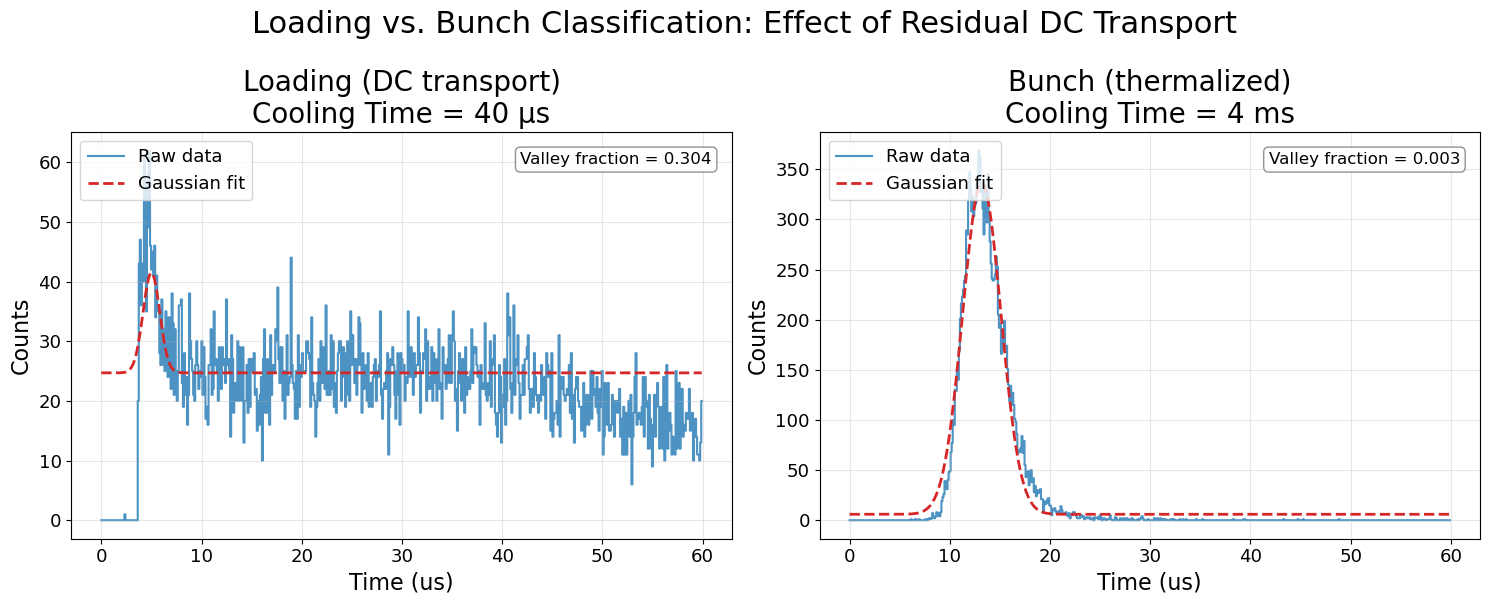

In [13]:
"""
Figure 3.11: Loading vs. Bunch Classification
------------------------------------------------
"""

def plot_loading_vs_bunch_example(run_num, loading_delay_us, bunch_delay_us,
                                    loading_filepath, bunch_filepath, tdc_window_us=60):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
    cfg = RUN_CONFIG[run_num]
    ns_per_channel = cfg["binwidth"] * 0.8

    configs = [
        (axes[0], loading_delay_us, loading_filepath, "Loading (DC transport)"),
        (axes[1], bunch_delay_us, bunch_filepath, "Bunch (thermalized)"),
    ]
    for ax, delay_us, filepath, label in configs:
        realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
        time_us = np.arange(len(counts)) * ns_per_channel / 1000
        mask = time_us <= tdc_window_us

        ax.step(time_us[mask], counts[mask], where='mid', color='tab:blue', alpha=0.8, label='Raw data', zorder=1)

        fit1 = fit_gaussian_peak(filepath, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
        if fit1 is not None:
            gaussian_full = gaussian(time_us, fit1["amplitude"], fit1["mu_us"], fit1["sigma_us"], fit1["offset"])
            ax.plot(time_us[mask], gaussian_full[mask], color='tab:red', linestyle='--', linewidth=2,
                     label='Gaussian fit', zorder=2)

            tail_frac = measure_tail_contamination(filepath, cfg["binwidth"], cfg["range"])
            valley_text = f"Valley fraction = {tail_frac:.3f}" if tail_frac is not None else "Valley fraction: N/A"
            ax.text(0.97, 0.95, valley_text, transform=ax.transAxes, ha='right', va='top', fontsize=12,
                     bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray"))

        ax.set_title(f"{label}\nCooling Time = {format_delay_label(delay_us)}", fontsize=20)
        ax.set_xlabel("Time (us)", fontsize=16)
        ax.set_ylabel("Counts", fontsize=16)
        ax.tick_params(axis='both', labelsize=13)
        ax.legend(fontsize=13, loc='upper left')
        ax.grid(True, alpha=0.3)

    fig.suptitle("Loading vs. Bunch Classification: Effect of Residual DC Transport", fontsize=22, y=1.00)
    plt.tight_layout()
    plt.show()


plot_loading_vs_bunch_example(
    run_num=1, loading_delay_us=40, bunch_delay_us=4000,
    loading_filepath="IonTrap/trap_40.mpa", bunch_filepath="IonTrap/trap_4000.mpa",
)

In [14]:
description = [
    "Loading vs. Bunch Classification: Effect of Residual DC Transport",
    "Corresponds to Figure 3.11",
    "",
    "Purpose: illustrates the classification criterion used to separate",
    "'loading' scans (storage time too short for ions to have finished",
    "traversing the axial DC gradient, leaving a residual DC-transport tail)",
    "from 'bunch' scans (well-thermalized, single-Gaussian ion population),",
    "as described in Section 3.6.4. Classification uses the valley fraction:",
    "the proportion of counts remaining at a fixed offset beyond the primary",
    "peak, relative to the peak height itself. Scans below a fixed valley-",
    "fraction threshold are classified as bunch quality and used for further",
    "analysis; the example bunch scan here has valley fraction 0.003, and",
    "the example loading scan has valley fraction 0.304.",
    "",
    "Columns:",
    "  category        - 'Loading' or 'Bunch'",
    "  storage_delay_us- Storage (trapping) time before extraction (us)",
    "  time_us         - Time-of-flight bin center, since exit aperture opens (us)",
    "  counts          - Raw TDC counts in this time bin",
    "  gaussian_fit    - Fitted single-Gaussian value at this time bin",
    "  r_squared       - Goodness-of-fit (R^2) of the single-Gaussian fit",
    "  valley_fraction - Residual tail contamination metric (Section 3.6.4)",
    "  file            - Source .mpa filename",
]

run_num = 1
loading_delay_us, bunch_delay_us = 40, 4000
loading_filepath, bunch_filepath = "IonTrap/trap_40.mpa", "IonTrap/trap_4000.mpa"
cfg = RUN_CONFIG[run_num]
ns_per_channel = cfg["binwidth"] * 0.8
tdc_window_us = 60

export_rows = []
for category, delay_us, filepath in [("Loading", loading_delay_us, loading_filepath),
                                       ("Bunch", bunch_delay_us, bunch_filepath)]:
    realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
    time_us = np.arange(len(counts)) * ns_per_channel / 1000
    mask = time_us <= tdc_window_us

    fit1 = fit_gaussian_peak(filepath, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
    gaussian_full = gaussian(time_us, fit1["amplitude"], fit1["mu_us"], fit1["sigma_us"], fit1["offset"]) if fit1 else np.full_like(time_us, np.nan)
    r2 = fit1["r2"] if fit1 else np.nan
    valley_frac = measure_tail_contamination(filepath, cfg["binwidth"], cfg["range"])

    for t, c, g in zip(time_us[mask], counts[mask], gaussian_full[mask]):
        export_rows.append({"category": category, "storage_delay_us": delay_us, "time_us": t,
                             "counts": c, "gaussian_fit": g, "r_squared": r2,
                             "valley_fraction": valley_frac, "file": filepath.split("/")[-1]})

export_df = pd.DataFrame(export_rows)
export_figure_csv(export_df, "thesis/loading_vs_bunch_classification.csv", description)
print(export_df.head())
archive_raw_files([loading_filepath.split("/")[-1], bunch_filepath.split("/")[-1]], "IonTrap", "loading_vs_bunch_classification")

  category  storage_delay_us  time_us  counts  gaussian_fit  r_squared  \
0  Loading                40   0.0000       0     24.693610   0.292376   
1  Loading                40   0.1024       0     24.693610   0.292376   
2  Loading                40   0.2048       0     24.693611   0.292376   
3  Loading                40   0.3072       0     24.693612   0.292376   
4  Loading                40   0.4096       0     24.693614   0.292376   

   valley_fraction         file  
0         0.304348  trap_40.mpa  
1         0.304348  trap_40.mpa  
2         0.304348  trap_40.mpa  
3         0.304348  trap_40.mpa  
4         0.304348  trap_40.mpa  
Copied 2 files to thesis/raw/loading_vs_bunch_classification


(['trap_40.mpa', 'trap_4000.mpa'], [])

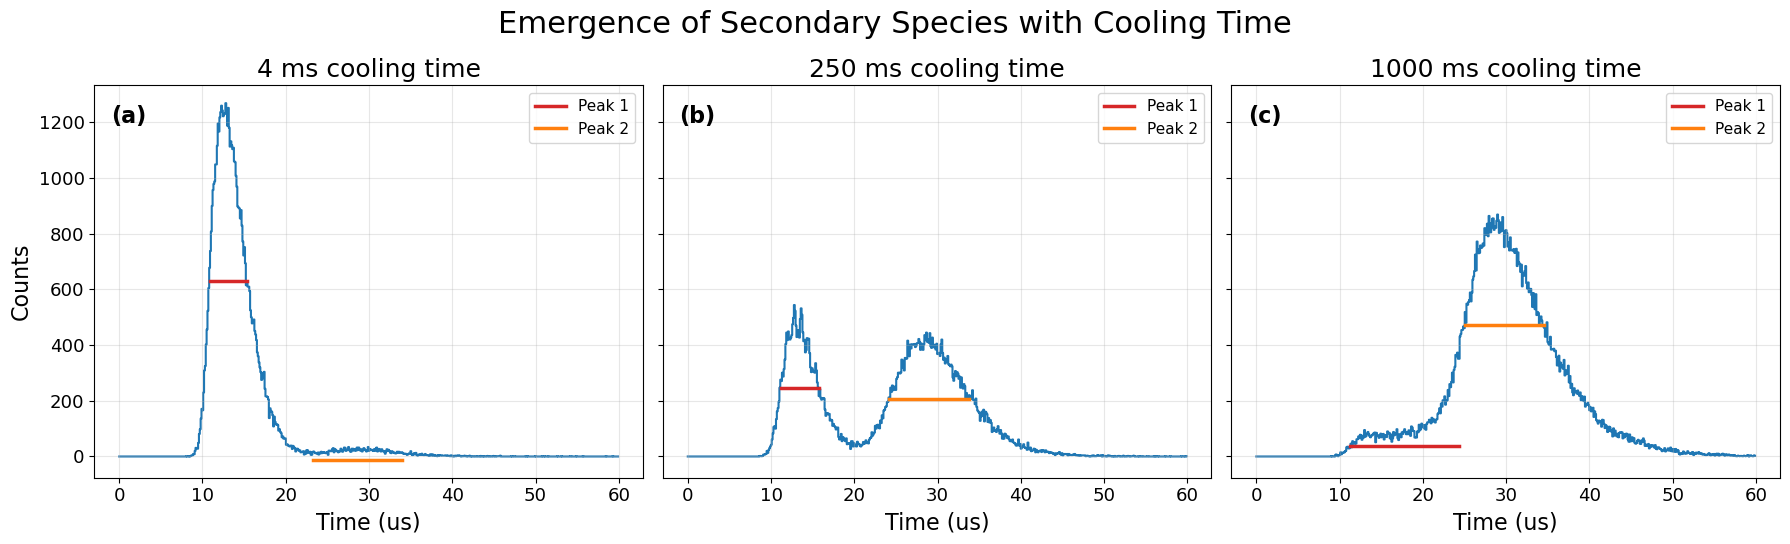

Peak 1 mean position: 13.187 us
Peak 2 mean position: 29.486 us


In [15]:
"""
Figure 4.2: Emergence of a Secondary Species with Storage Time
--------------------------------------------------------------------
The mean arrival times of Peak 1 and Peak 2, computed below, support the
mass-ratio identification discussed after this figure (a mass ratio of
~5.0 relative to primary-peak 85Rb+, consistent with Rb+(H2O)19).
"""

def plot_contamination_emergence(run_num, delays_ms, example_files, tdc_window_us=60):
    """delays_ms: list of 3 delay labels (ms) for titling.
    example_files: list of 3 filepaths, matching delays_ms in order."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)
    cfg = RUN_CONFIG[run_num]
    ns_per_channel = cfg["binwidth"] * 0.8
    panel_labels = ["(a)", "(b)", "(c)"]

    for ax, delay_ms, filepath, label in zip(axes, delays_ms, example_files, panel_labels):
        realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
        time_us = np.arange(len(counts)) * ns_per_channel / 1000
        mask = time_us <= tdc_window_us
        ax.step(time_us[mask], counts[mask], where='mid', color=RUN_COLORS[run_num], zorder=1)

        fit1 = fit_gaussian_peak(filepath, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
        if fit1 is not None:
            fwhm1 = fit1["sigma_us"] * 2.3548
            mu1 = fit1["mu_us"]
            half_max_y1 = fit1["amplitude"]/2 + fit1["offset"]
            ax.plot([mu1-fwhm1/2, mu1+fwhm1/2], [half_max_y1, half_max_y1],
                     color='tab:red', linewidth=2.5, zorder=3, label='Peak 1')

            gaussian_full = gaussian(time_us, fit1["amplitude"], fit1["mu_us"], fit1["sigma_us"], fit1["offset"])
            residual = counts - gaussian_full
            fit2 = fit_gaussian_on_residual(residual, time_us, window=(22, 45))
            if fit2 is not None:
                fwhm2 = fit2["sigma_us"] * 2.3548
                mu2 = fit2["mu_us"]
                half_max_y2 = fit2["amplitude"]/2 + fit2["offset"]
                ax.plot([mu2-fwhm2/2, mu2+fwhm2/2], [half_max_y2, half_max_y2],
                         color='tab:orange', linewidth=2.5, zorder=3, label='Peak 2')

        ax.text(0.03, 0.95, label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')
        ax.set_title(f"{delay_ms} ms cooling time", fontsize=18)
        ax.set_xlabel("Time (us)", fontsize=16)
        ax.tick_params(axis='both', labelsize=13)
        ax.legend(fontsize=11, loc='upper right')
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Counts", fontsize=16)
    fig.suptitle("Emergence of Secondary Species with Cooling Time", fontsize=22, y=0.98)
    plt.tight_layout()
    plt.show()


plot_contamination_emergence(
    run_num=4, delays_ms=[4, 250, 1000],
    example_files=["IonTrap/trap_4000_3.mpa", "IonTrap/trap_250000_3.mpa", "IonTrap/trap_1000000_3.mpa"]
)


def get_peak_positions(filepath, run_num):
    cfg = RUN_CONFIG[run_num]
    fit1 = fit_gaussian_peak(filepath, window=(5, 20), binwidth=cfg["binwidth"], channels=cfg["range"])
    if fit1 is None:
        return None, None
    realtime, totalsum, counts = read_mpa_histogram(filepath, cfg["range"])
    ns_per_channel = cfg["binwidth"] * 0.8
    time_us = np.arange(len(counts)) * ns_per_channel / 1000
    gaussian_full = gaussian(time_us, fit1["amplitude"], fit1["mu_us"], fit1["sigma_us"], fit1["offset"])
    residual = counts - gaussian_full
    fit2 = fit_gaussian_on_residual(residual, time_us, window=(22, 45))
    return fit1["mu_us"], (fit2["mu_us"] if fit2 else None)


mu1_list, mu2_list = [], []
for _, r in trap_df[(trap_df["quality"]=="bunch") & (~trap_df["is_control"])].iterrows():
    m1, m2 = get_peak_positions(r["filepath"], r["run"])
    if m1: mu1_list.append(m1)
    if m2: mu2_list.append(m2)

print(f"Peak 1 mean position: {np.mean(mu1_list):.3f} us")
print(f"Peak 2 mean position: {np.mean(mu2_list):.3f} us")

Run 2 (Low Pressure): tau = 1215.4 +/- 50.3 ms (chi2/dof = 21.54, scale factor = 4.64)
Run 3 (High Pressure): tau = 225.6 +/- 14.3 ms (chi2/dof = 557.03, scale factor = 23.60)


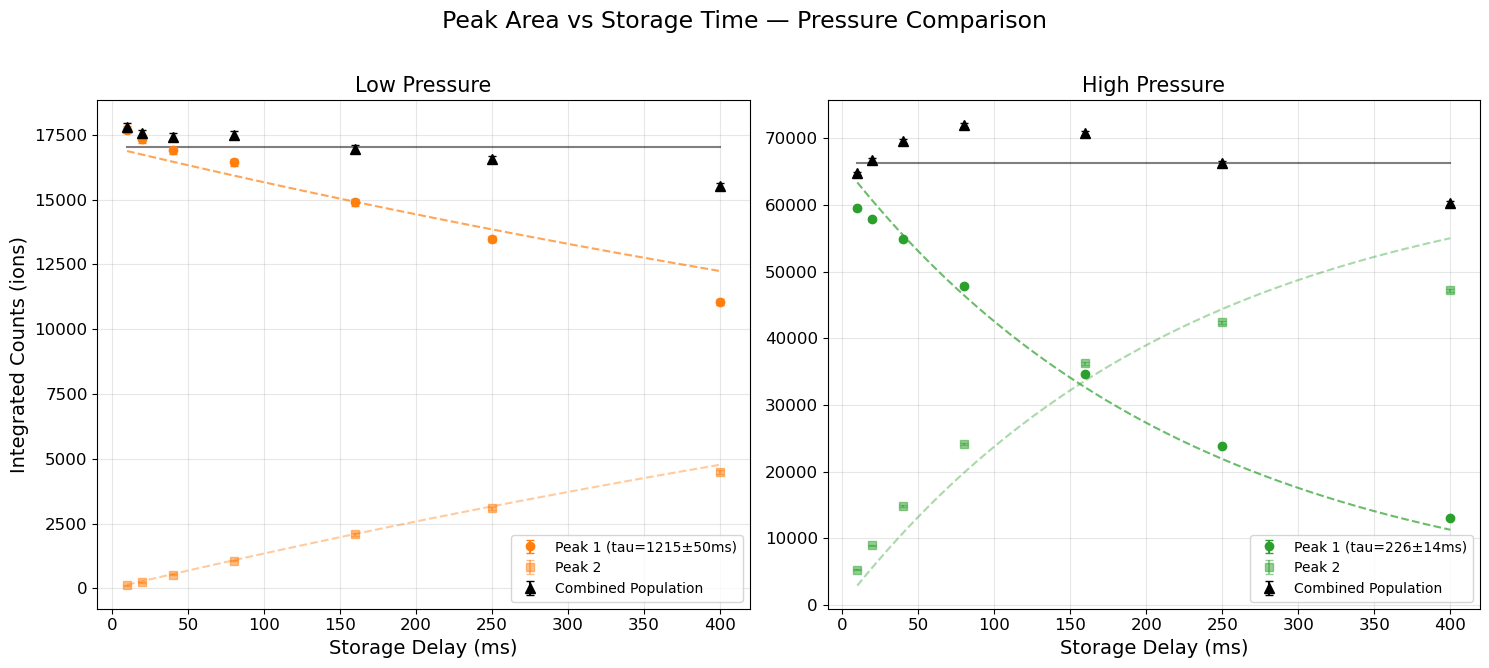

Run 3 (Long Teflon Tubing): tau = 225.6 +/- 14.3 ms (chi2/dof = 557.03, scale factor = 23.60)
Run 4 (Short Copper Tubing): tau = 530.6 +/- 41.9 ms (chi2/dof = 489.03, scale factor = 22.11)


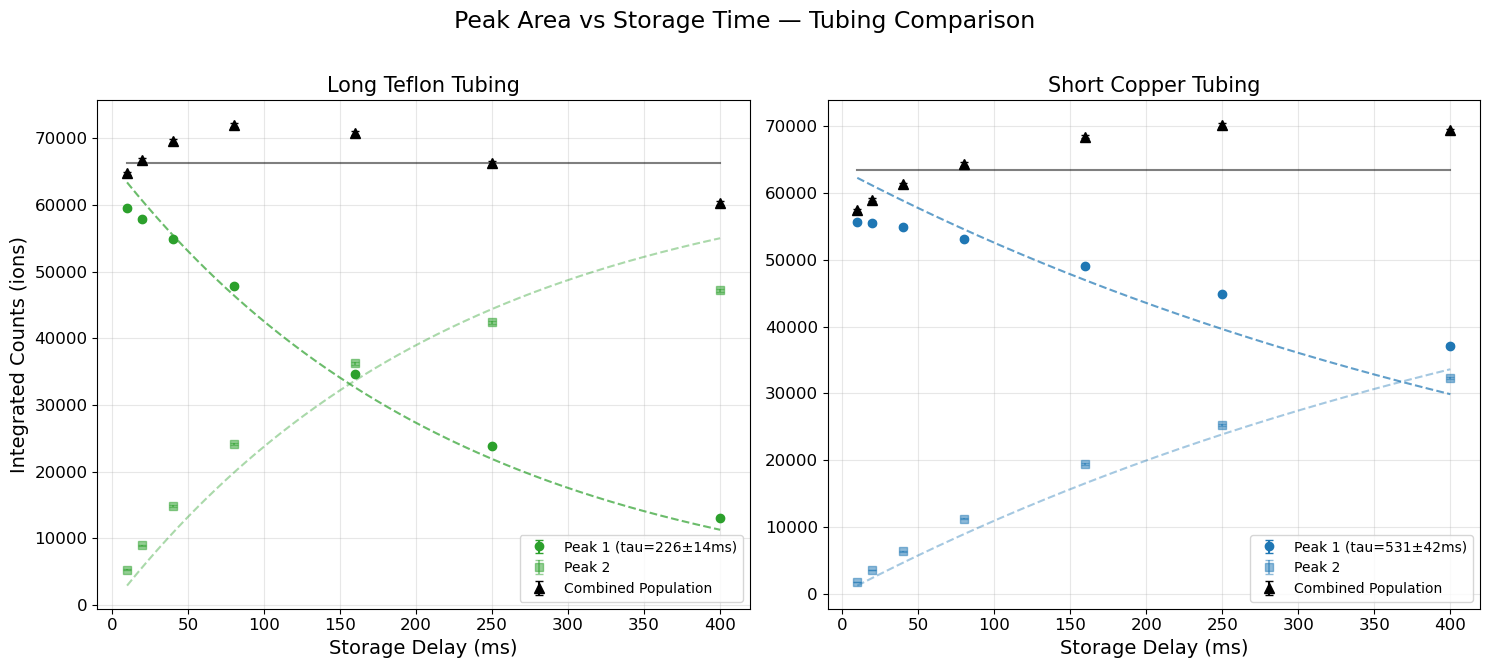

In [16]:
"""
Figures 4.3 and 4.4: Peak Area vs. Storage Time -- Pressure and Tubing
Comparison
----------------------------------------------------------------------------
Two-state conversion model (Eq. 4.1): N1(t)=N0*exp(-kt), N2(t)=N0*(1-exp(-kt)),
fit via weighted least squares with Poisson uncertainties on each peak area,
giving a shared conversion time constant tau=1/k per run.
"""

def two_state_conversion(t, N0, k):
    N1 = N0 * np.exp(-k * t)
    N2 = N0 * (1 - np.exp(-k * t))
    return N1, N2


def two_state_residuals_weighted(params, t, y1_data, y2_data, y1_err, y2_err):
    N0, k = params
    N1_pred, N2_pred = two_state_conversion(t, N0, k)
    return np.concatenate([(y1_data - N1_pred) / y1_err, (y2_data - N2_pred) / y2_err])


def plot_storage_comparison(run_a, run_b, lower_us, upper_us, title, panel_labels=None):
    if panel_labels is None:
        panel_labels = {}

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

    for ax, run_num in zip(axes, [run_a, run_b]):
        panel_title = panel_labels.get(run_num, f"Run {run_num}")
        color = RUN_COLORS[run_num]
        group = dual_peak_df[(dual_peak_df["run"]==run_num) &
                              (dual_peak_df["delay_us"] >= lower_us) &
                              (dual_peak_df["delay_us"] <= upper_us)].sort_values("delay_us")
        if group.empty:
            ax.set_title(f"{panel_title} (no data)", fontsize=15)
            continue

        t_s = group["delay_us"].values * 1e-6
        y1, y2 = group["peak1_area"].values, group["peak2_area"].values
        y_sum = group["combined_area"].values
        y1_err = np.sqrt(np.maximum(y1, 1))
        y2_err = np.sqrt(np.maximum(y2, 1))
        y_sum_err = np.sqrt(y1_err**2 + y2_err**2)

        tau_label = ""
        if len(group) >= 3:
            p0 = [group["combined_area"].mean(), 1.0]
            try:
                result = least_squares(two_state_residuals_weighted, p0, args=(t_s, y1, y2, y1_err, y2_err))
                N0, k = result.x
                tau = 1/k

                J = result.jac
                cov = np.linalg.inv(J.T @ J)
                k_err_stat = np.sqrt(cov[1,1])

                chi2 = np.sum(result.fun**2)
                dof = 2*len(t_s) - 2
                chi2_dof = chi2/dof if dof > 0 else np.nan
                scale = np.sqrt(chi2_dof) if chi2_dof > 1 else 1.0
                k_err = k_err_stat * scale
                tau_err = k_err / k**2

                print(f"Run {run_num} ({panel_title}): tau = {tau*1000:.1f} +/- {tau_err*1000:.1f} ms "
                      f"(chi2/dof = {chi2_dof:.2f}, scale factor = {scale:.2f})")

                t_fit = np.linspace(t_s.min(), t_s.max(), 300)
                N1_fit, N2_fit = two_state_conversion(t_fit, N0, k)
                ax.plot(t_fit*1000, N1_fit, "--", color=color, alpha=0.7)
                ax.plot(t_fit*1000, N2_fit, "--", color=color, alpha=0.4)
                ax.plot(t_fit*1000, N1_fit + N2_fit, "-", color="black", alpha=0.5, linewidth=1.5)
                tau_label = f" (tau={tau*1000:.0f}\u00b1{tau_err*1000:.0f}ms)"
            except Exception as e:
                print(f"Run {run_num} fit failed: {e}")

        ax.errorbar(t_s*1000, y1, yerr=y1_err, fmt="o", color=color, capsize=3, label=f"Peak 1{tau_label}")
        ax.errorbar(t_s*1000, y2, yerr=y2_err, fmt="s", color=color, alpha=0.5, capsize=3, label="Peak 2")
        ax.errorbar(t_s*1000, y_sum, yerr=y_sum_err, fmt="^", color="black", capsize=3,
                     label="Combined Population", markersize=7)

        ax.set_xlabel("Storage Delay (ms)", fontsize=14)
        ax.set_title(panel_title, fontsize=15)
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Integrated Counts (ions)", fontsize=14)
    fig.suptitle(title, fontsize=17, y=1.02)
    plt.tight_layout()
    plt.show()


plot_storage_comparison(2, 3, 10_000, 400_000, "Peak Area vs Storage Time — Pressure Comparison",
                          panel_labels={2: "Low Pressure", 3: "High Pressure"})
plot_storage_comparison(3, 4, 10_000, 400_000, "Peak Area vs Storage Time — Tubing Comparison",
                          panel_labels={3: "Long Teflon Tubing", 4: "Short Copper Tubing"})

In [17]:
# Combined-population consistency check: confirms total (Peak1+Peak2) counts
# stay approximately constant across storage time in each condition, as
# claimed in the Figure 4.3/4.4 discussion.
for run_num in [2, 3, 4]:
    group = dual_peak_df[(dual_peak_df["run"]==run_num) &
                          (dual_peak_df["delay_us"] >= 10_000) &
                          (dual_peak_df["delay_us"] <= 400_000)]
    if group.empty:
        continue
    y1, y2 = group["peak1_area"].values, group["peak2_area"].values
    y_sum = group["combined_area"].values
    y_sum_err = np.sqrt(np.maximum(y1,1) + np.maximum(y2,1))

    weights = 1/y_sum_err**2
    weighted_mean = np.sum(y_sum*weights)/np.sum(weights)
    chi2 = np.sum(((y_sum - weighted_mean)/y_sum_err)**2)
    dof = len(y_sum) - 1
    rel_spread = y_sum.std()/y_sum.mean()*100

    print(f"Run {run_num}: weighted mean combined area = {weighted_mean:.0f}, "
          f"relative spread = {rel_spread:.1f}%, chi2/dof = {chi2/dof:.2f}, n={len(y_sum)}")

Run 2: weighted mean combined area = 17017, relative spread = 4.3%, chi2/dof = 38.39, n=7
Run 3: weighted mean combined area = 67015, relative spread = 5.5%, chi2/dof = 246.91, n=7
Run 4: weighted mean combined area = 63956, relative spread = 7.5%, chi2/dof = 424.51, n=7


In [18]:
# Combined-population consistency check: confirms total (Peak1+Peak2) counts
# stay approximately constant across storage time in each condition, as
# claimed in the Figure 4.3/4.4 discussion.
for run_num in [2, 3, 4]:
    group = dual_peak_df[(dual_peak_df["run"]==run_num) &
                          (dual_peak_df["delay_us"] >= 10_000) &
                          (dual_peak_df["delay_us"] <= 400_000)]
    if group.empty:
        continue
    y1, y2 = group["peak1_area"].values, group["peak2_area"].values
    y_sum = group["combined_area"].values
    y_sum_err = np.sqrt(np.maximum(y1,1) + np.maximum(y2,1))

    weights = 1/y_sum_err**2
    weighted_mean = np.sum(y_sum*weights)/np.sum(weights)
    chi2 = np.sum(((y_sum - weighted_mean)/y_sum_err)**2)
    dof = len(y_sum) - 1
    rel_spread = y_sum.std()/y_sum.mean()*100

    print(f"Run {run_num}: weighted mean combined area = {weighted_mean:.0f}, "
          f"relative spread = {rel_spread:.1f}%, chi2/dof = {chi2/dof:.2f}, n={len(y_sum)}")

Run 2: weighted mean combined area = 17017, relative spread = 4.3%, chi2/dof = 38.39, n=7
Run 3: weighted mean combined area = 67015, relative spread = 5.5%, chi2/dof = 246.91, n=7
Run 4: weighted mean combined area = 63956, relative spread = 7.5%, chi2/dof = 424.51, n=7


In [19]:
description = [
    "Peak 1 and Peak 2 Integrated Area vs. Storage Time -- Pressure and",
    "Tubing Comparison",
    "Corresponds to Figures 4.3 and 4.4",
    "",
    "Purpose: identifies the source of a slow chemical conversion of the",
    "trapped primary ion population into a heavier secondary species (a",
    "hydrated rubidium cluster, tentatively Rb+(H2O)19; Section 4.2.1),",
    "observed as ions are stored in the PCB RFQ. Peak 1 and Peak 2 areas are",
    "modeled as a two-state conversion process, N1(t)=N0*exp(-kt),",
    "N2(t)=N0*(1-exp(-kt)), giving a characteristic conversion time constant",
    "tau=1/k.",
    "",
    "Figure 4.3 compares low buffer gas pressure (~4.4e-3 mbar) against high",
    "pressure (~6.1e-2 mbar): tau decreases from ~1215ms to ~226ms, a",
    "pressure-dependent rate consistent with the water source being the",
    "helium gas supply rather than intrinsic PCB outgassing.",
    "",
    "Figure 4.4 compares the same high-pressure condition before and after",
    "replacing the gas inlet's long (~4m) PTFE tubing with shorter (~1.5m)",
    "copper tubing: tau increases from ~226ms to ~531ms, consistent with",
    "water permeating through or outgassing from the more porous PTFE",
    "tubing itself.",
    "",
    "In all conditions, the combined (Peak1+Peak2) area remains approximately",
    "constant across storage time, indicating population is redistributed",
    "between the two states rather than lost from the trap.",
    "",
    "Columns:",
    "  condition       - Measurement condition: 'Low Pressure', 'High Pressure",
    "                    (PTFE Tubing)', or 'High Pressure (Copper Tubing)'",
    "  storage_delay_ms- Storage (trapping) time before extraction (ms)",
    "  peak1_area      - Integrated counts, primary (Peak 1) population",
    "  peak1_area_err  - Poisson uncertainty on peak1_area",
    "  peak2_area      - Integrated counts, secondary (Peak 2) population",
    "  peak2_area_err  - Poisson uncertainty on peak2_area",
    "  combined_area   - peak1_area + peak2_area",
    "  combined_area_err - Propagated uncertainty on combined_area",
]

condition_map = {2: "Low Pressure", 3: "High Pressure (PTFE Tubing)", 4: "High Pressure (Copper Tubing)"}
lower_us, upper_us = 10_000, 400_000
export_rows = []

for run_num, condition in condition_map.items():
    group = dual_peak_df[(dual_peak_df["run"]==run_num) &
                          (dual_peak_df["delay_us"] >= lower_us) &
                          (dual_peak_df["delay_us"] <= upper_us)].sort_values("delay_us")
    y1, y2 = group["peak1_area"].values, group["peak2_area"].values
    y1_err = np.sqrt(np.maximum(y1, 1))
    y2_err = np.sqrt(np.maximum(y2, 1))
    y_sum_err = np.sqrt(y1_err**2 + y2_err**2)

    for delay_us, p1, p1e, p2, p2e, comb, combe in zip(
        group["delay_us"], y1, y1_err, y2, y2_err, group["combined_area"], y_sum_err
    ):
        export_rows.append({"condition": condition, "storage_delay_ms": delay_us / 1000,
                             "peak1_area": p1, "peak1_area_err": p1e, "peak2_area": p2,
                             "peak2_area_err": p2e, "combined_area": comb, "combined_area_err": combe})

export_df = pd.DataFrame(export_rows)
export_figure_csv(export_df, "thesis/secondary_species_pressure_tubing_comparison.csv", description)
print(export_df)

                        condition  storage_delay_ms  peak1_area  \
0                    Low Pressure              10.0       17688   
1                    Low Pressure              20.0       17319   
2                    Low Pressure              40.0       16902   
3                    Low Pressure              80.0       16437   
4                    Low Pressure             160.0       14889   
5                    Low Pressure             250.0       13470   
6                    Low Pressure             400.0       11043   
7     High Pressure (PTFE Tubing)              10.0       59523   
8     High Pressure (PTFE Tubing)              20.0       57854   
9     High Pressure (PTFE Tubing)              40.0       54837   
10    High Pressure (PTFE Tubing)              80.0       47906   
11    High Pressure (PTFE Tubing)             160.0       34610   
12    High Pressure (PTFE Tubing)             250.0       23896   
13    High Pressure (PTFE Tubing)             400.0       1307